# 🛠️ Feature Engineering for Fraud Detection

## 📌 Purpose

This notebook transforms **raw PaySim transaction data** into **ML-ready features** using insights from our comprehensive EDA.

### Feature Engineering Philosophy

1. 🎯 **Quality over Quantity**: Focus on high-impact features
2. 🧠 **Domain-Driven**: Based on fraud detection best practices
3. ⚙️ **Production-Ready**: Sklearn pipeline for deployment
4. ✅ **Validated**: No data leakage, proper splits

---

## 🎯 Feature Engineering Strategy (Based on EDA)

### From EDA Insights to Features

| EDA Finding | Feature Engineering Action | Feature Name |
|-------------|---------------------------|-------------|
| Fraud only in TRANSFER & CASH_OUT | One-hot encode transaction type | `type_*` |
| Hour-based fraud patterns | Extract hour of day | `hour` |
| 100% fraud targets customers (C→C) | Flag merchant destinations | `is_merchant_dest` |
| Balance inconsistencies in fraud | Compute balance errors | `error_balance_orig/dest` |
| Amount is right-skewed | Log transformation | `amount_log` |
| Fraud empties accounts | Flag account drain | `is_origin_drained` |

### Features We'll Create (Streamlined)

**Total: 15 engineered features + original numerical features**

1. **Temporal Features** (2)
   - `hour`: Hour of day (0-23)
   - `day`: Day of simulation

2. **Balance Error Features** (2)
   - `error_balance_orig`: Origin balance inconsistency
   - `error_balance_dest`: Destination balance inconsistency

3. **Amount Features** (2)
   - `amount_log`: Log-transformed amount
   - `amount_to_balance_ratio`: Transaction relative to sender balance

4. **Pattern Features** (5)
   - `is_merchant_dest`: Customer vs Merchant destination
   - `is_origin_drained`: Complete account drain flag
   - `is_high_amount`: Large transaction flag (>200k)
   - `is_high_risk_type`: TRANSFER or CASH_OUT
   - `is_night_transaction`: Late night hours (0-5)

5. **Interaction Features** (4)
   - `high_risk_night`: High-risk type during night
   - `high_amount_c2c`: Large customer-to-customer transfer
   - `drained_non_merchant`: Account drained to customer
   - `error_to_amount_ratio`: Balance error relative to amount

---

## 1. Setup & Imports

All artifacts will be saved to `../artifacts/` (main project artifacts folder).

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Serialization
import joblib
import pickle
import os
import warnings
from datetime import datetime

# Configuration
warnings.filterwarnings('ignore')
np.random.seed(42)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', None)

# Plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ Libraries imported successfully!')

# Verify main artifacts folder exists (one level up)
artifacts_path = '../artifacts'
if not os.path.exists(artifacts_path):
    raise FileNotFoundError(
        f"Main artifacts folder not found at '{artifacts_path}'. "
        f"Please ensure you're running this notebook from the 'notebooks/' directory."
    )

# Create subdirectories
os.makedirs(f'{artifacts_path}/data', exist_ok=True)

print('✅ All artifacts will be saved to the main project artifacts folder')

✅ Libraries imported successfully!
✅ All artifacts will be saved to the main project artifacts folder


---
## 2. Load Data

### Data Loading Strategy

- Load the full PaySim dataset (6.36M rows)
- Verify data integrity
- Save raw data backup to artifacts

In [2]:
# Load dataset
file_path = "data/paysim_fraud_data.csv"

print('⏳ Loading dataset...')
df = pd.read_csv(file_path)

print('✅ Dataset loaded successfully!')
print('=' * 80)
print(f'📊 Shape: {df.shape}')
print(f'📊 Rows: {len(df):,}')
print(f'📊 Columns: {df.shape[1]}')
print(f'📊 Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print(f'📊 Fraud rate: {df["isFraud"].mean() * 100:.4f}%')
print('=' * 80)

# Save raw data backup
print('\n💾 Saving raw data backup...')
df.to_csv('../artifacts/data/raw_data.csv', index=False)
print('✅ Saved: ../artifacts/data/raw_data.csv')

# Display first rows
print('\n👀 First 5 rows:')
display(df.head())

# Quick data quality check
print('\n🔍 Data Quality Check:')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Transaction types: {df["type"].unique().tolist()}')

⏳ Loading dataset...
✅ Dataset loaded successfully!
📊 Shape: (6362620, 11)
📊 Rows: 6,362,620
📊 Columns: 11
📊 Memory: 1598.19 MB
📊 Fraud rate: 0.1291%

💾 Saving raw data backup...
✅ Saved: ../artifacts/data/raw_data.csv

👀 First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.64",C1231006815,"170,136.00","160,296.36",M1979787155,0.00,0.00,0,0
1,1,PAYMENT,"1,864.28",C1666544295,"21,249.00","19,384.72",M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0
4,1,PAYMENT,"11,668.14",C2048537720,"41,554.00","29,885.86",M1230701703,0.00,0.00,0,0



🔍 Data Quality Check:
Missing values: 0
Duplicate rows: 0
Transaction types: ['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN']


---
## 3. Feature Engineering Functions

### Design Philosophy

We create **modular functions** for each feature category:
- ✅ **Reusable**: Can be applied to train and test data
- ✅ **Testable**: Each function can be validated independently
- ✅ **Production-ready**: Can be integrated into sklearn pipelines

### Streamlined Feature Set

We focus on **15 high-impact engineered features** rather than creating dozens of potentially redundant features.

In [3]:
def create_temporal_features(df):
    """
    Create time-based features.
    
    Features:
    - hour: Hour of day (0-23)
    - day: Day of simulation (0-30)
    """
    print('\n⚙️ Creating temporal features...')
    
    df['hour'] = df['step'] % 24
    df['day'] = (df['step'] // 24).astype(int)
    
    print(f'  ✅ hour (range: {df["hour"].min()}-{df["hour"].max()})')
    print(f'  ✅ day (range: {df["day"].min()}-{df["day"].max()})')
    
    return df


def create_balance_features(df):
    """
    Engineer balance-related features that capture inconsistencies.
    
    Features:
    - error_balance_orig: Deviation from expected origin balance
    - error_balance_dest: Deviation from expected destination balance
    - error_to_amount_ratio: Error relative to transaction amount
    - is_origin_drained: Flag for complete account drain
    """
    print('\n⚙️ Creating balance features...')
    
    # Balance errors (deviation from expected)
    df['error_balance_orig'] = (df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig'])
    df['error_balance_dest'] = (df['oldbalanceDest'] + df['amount'] - df['newbalanceDest'])
    
    # Combined error ratio (absolute error relative to amount)
    total_error = np.abs(df['error_balance_orig']) + np.abs(df['error_balance_dest'])
    df['error_to_amount_ratio'] = np.where(
        df['amount'] > 0,
        total_error / df['amount'],
        0
    )
    
    # Account drain flag (origin account emptied)
    df['is_origin_drained'] = (
        (df['oldbalanceOrg'] > 0) & 
        (df['newbalanceOrig'] == 0)
    ).astype(int)
    
    print(f'  ✅ error_balance_orig, error_balance_dest')
    print(f'  ✅ error_to_amount_ratio')
    print(f'  ✅ is_origin_drained ({df["is_origin_drained"].sum():,} cases)')
    
    return df


def create_amount_features(df):
    """
    Create amount-based features.
    
    Features:
    - amount_log: Log-transformed amount
    - amount_to_balance_ratio: Transaction relative to sender's balance
    - is_high_amount: Flag for amounts > 200,000
    """
    print('\n⚙️ Creating amount features...')
    
    # Log transformation (handles skewness)
    df['amount_log'] = np.log1p(df['amount'])
    
    # Amount relative to origin balance
    df['amount_to_balance_ratio'] = np.where(
        df['oldbalanceOrg'] > 0,
        df['amount'] / df['oldbalanceOrg'],
        0
    )
    
    # High amount flag (same threshold as isFlaggedFraud)
    df['is_high_amount'] = (df['amount'] > 200000).astype(int)
    
    print(f'  ✅ amount_log')
    print(f'  ✅ amount_to_balance_ratio')
    print(f'  ✅ is_high_amount ({df["is_high_amount"].sum():,} cases)')
    
    return df


def create_pattern_features(df):
    """
    Create features capturing suspicious patterns.
    
    Features:
    - is_merchant_dest: Merchant destination flag
    - is_night_transaction: Flag for late night hours (0-5)
    - is_high_risk_type: Flag for TRANSFER or CASH_OUT
    """
    print('\n⚙️ Creating pattern features...')
    
    # Destination type (M = Merchant, C = Customer)
    df['is_merchant_dest'] = df['nameDest'].str.startswith('M').astype(int)
    
    # Night transaction (higher fraud risk)
    df['is_night_transaction'] = df['hour'].isin([0, 1, 2, 3, 4, 5]).astype(int)
    
    # High-risk transaction type (from EDA)
    df['is_high_risk_type'] = df['type'].isin(['TRANSFER', 'CASH_OUT']).astype(int)
    
    print(f'  ✅ is_merchant_dest ({df["is_merchant_dest"].sum():,} merchants)')
    print(f'  ✅ is_night_transaction ({df["is_night_transaction"].sum():,} cases)')
    print(f'  ✅ is_high_risk_type ({df["is_high_risk_type"].sum():,} cases)')
    
    return df


def create_interaction_features(df):
    """
    Create interaction features (combinations indicating higher risk).
    
    Features:
    - high_risk_night: High-risk type during night hours
    - high_amount_c2c: Large customer-to-customer transaction
    - drained_non_merchant: Account drained to non-merchant
    """
    print('\n⚙️ Creating interaction features...')
    
    # High-risk type during night
    df['high_risk_night'] = (
        df['is_high_risk_type'] & df['is_night_transaction']
    ).astype(int)
    
    # High amount to customer (not merchant)
    df['high_amount_c2c'] = (
        (df['is_high_amount'] == 1) & 
        (df['is_merchant_dest'] == 0)
    ).astype(int)
    
    # Account drained to non-merchant
    df['drained_non_merchant'] = (
        (df['is_origin_drained'] == 1) & 
        (df['is_merchant_dest'] == 0)
    ).astype(int)
    
    print(f'  ✅ high_risk_night ({df["high_risk_night"].sum():,} cases)')
    print(f'  ✅ high_amount_c2c ({df["high_amount_c2c"].sum():,} cases)')
    print(f'  ✅ drained_non_merchant ({df["drained_non_merchant"].sum():,} cases)')
    
    return df


def engineer_all_features(df):
    """
    Master function to create all engineered features.
    
    Args:
        df: Raw transaction dataframe
    
    Returns:
        df: Dataframe with all engineered features
    """
    print('\n' + '='*80)
    print('🚀 FEATURE ENGINEERING PIPELINE')
    print('='*80)
    
    original_cols = len(df.columns)
    
    # Apply all feature engineering functions
    df = create_temporal_features(df)
    df = create_balance_features(df)
    df = create_amount_features(df)
    df = create_pattern_features(df)
    df = create_interaction_features(df)
    
    new_cols = len(df.columns) - original_cols
    
    print('\n' + '='*80)
    print(f'✅ FEATURE ENGINEERING COMPLETE')
    print('='*80)
    print(f'📊 Original features: {original_cols}')
    print(f'📊 New features created: {new_cols}')
    print(f'📊 Total features: {len(df.columns)}')
    print('='*80)
    
    return df


print('✅ Feature engineering functions defined!')

✅ Feature engineering functions defined!


---
## 4. Apply Feature Engineering

### What Happens Here

We apply our feature engineering functions to the entire dataset:
- Create 15 new high-impact features
- Validate feature distributions
- Check for any issues

In [4]:
# Apply feature engineering
df_engineered = engineer_all_features(df.copy())

# Display sample with new features
print('\n👀 Sample with engineered features:')
new_feature_cols = [
    'amount', 'amount_log', 'hour', 'day', 'is_merchant_dest',
    'error_balance_orig', 'error_balance_dest', 'error_to_amount_ratio',
    'is_origin_drained', 'is_high_amount', 'is_high_risk_type',
    'high_risk_night', 'drained_non_merchant', 'isFraud'
]
display(df_engineered[new_feature_cols].head(10))


🚀 FEATURE ENGINEERING PIPELINE

⚙️ Creating temporal features...
  ✅ hour (range: 0-23)
  ✅ day (range: 0-30)

⚙️ Creating balance features...
  ✅ error_balance_orig, error_balance_dest
  ✅ error_to_amount_ratio
  ✅ is_origin_drained (1,520,581 cases)

⚙️ Creating amount features...
  ✅ amount_log
  ✅ amount_to_balance_ratio
  ✅ is_high_amount (1,673,570 cases)

⚙️ Creating pattern features...
  ✅ is_merchant_dest (2,151,495 merchants)
  ✅ is_night_transaction (112,605 cases)
  ✅ is_high_risk_type (2,770,409 cases)

⚙️ Creating interaction features...
  ✅ high_risk_night (28,065 cases)
  ✅ high_amount_c2c (1,673,564 cases)
  ✅ drained_non_merchant (1,193,702 cases)

✅ FEATURE ENGINEERING COMPLETE
📊 Original features: 11
📊 New features created: 15
📊 Total features: 26

👀 Sample with engineered features:


,amount,amount_log,hour,day,is_merchant_dest,error_balance_orig,error_balance_dest,error_to_amount_ratio,is_origin_drained,is_high_amount,is_high_risk_type,high_risk_night,drained_non_merchant,isFraud
0,"9,839.64",9.19,1,0,1,0.00,"9,839.64",1.00,0,0,0,0,0,0
1,"1,864.28",7.53,1,0,1,0.00,"1,864.28",1.00,0,0,0,0,0,0
2,181.00,5.20,1,0,0,0.00,181.00,1.00,1,0,1,1,1,1
3,181.00,5.20,1,0,0,0.00,"21,363.00",118.03,1,0,1,1,1,1
4,"11,668.14",9.36,1,0,1,0.00,"11,668.14",1.00,0,0,0,0,0,0
5,"7,817.71",8.96,1,0,1,0.00,"7,817.71",1.00,0,0,0,0,0,0
6,"7,107.77",8.87,1,0,1,0.00,"7,107.77",1.00,0,0,0,0,0,0
7,"7,861.64",8.97,1,0,1,0.00,"7,861.64",1.00,0,0,0,0,0,0
8,"4,024.36",8.30,1,0,1,"-1,353.36","4,024.36",1.34,1,0,0,0,0,0
9,"5,337.77",8.58,1,0,0,-0.00,"6,886.98",1.29,0,0,0,0,0,0


---
## 5. Feature Validation

### Why Validate Features?

Before modeling, we must verify:
- No NaN or infinite values
- Reasonable value ranges
- Feature distributions make sense

In [5]:
print('\n' + '='*80)
print('🔍 FEATURE VALIDATION')
print('='*80)

# Check for issues
print('\n1️⃣ Checking for NaN values:')
nan_counts = df_engineered.isnull().sum()
if nan_counts.sum() > 0:
    print('⚠️  NaN values found:')
    print(nan_counts[nan_counts > 0])
else:
    print('✅ No NaN values found')

print('\n2️⃣ Checking for infinite values:')
inf_cols = []
for col in df_engineered.select_dtypes(include=[np.number]).columns:
    if np.isinf(df_engineered[col]).any():
        inf_cols.append(col)
        
if inf_cols:
    print(f'⚠️  Infinite values found in: {inf_cols}')
else:
    print('✅ No infinite values found')

print('\n3️⃣ Engineered features summary:')
engineered_features = [
    'hour', 'day', 'amount_log', 'error_balance_orig', 'error_balance_dest',
    'error_to_amount_ratio', 'amount_to_balance_ratio', 'is_merchant_dest',
    'is_origin_drained', 'is_high_amount'
]
display(df_engineered[engineered_features].describe())

print('='*80)


🔍 FEATURE VALIDATION

1️⃣ Checking for NaN values:
✅ No NaN values found

2️⃣ Checking for infinite values:
✅ No infinite values found

3️⃣ Engineered features summary:


,hour,day,amount_log,error_balance_orig,error_balance_dest,error_to_amount_ratio,amount_to_balance_ratio,is_merchant_dest,is_origin_drained,is_high_amount
count,"6,362,620.00","6,362,620.00","6,362,620.00","6,362,620.00","6,362,620.00","6,362,620.00","6,362,620.00","6,362,620.00","6,362,620.00","6,362,620.00"
mean,15.32,9.50,10.84,"-201,092.47","55,567.17",2.59,81.71,0.34,0.24,0.26
std,4.32,5.92,1.81,"606,650.46","441,528.77",254.78,"3,395.71",0.47,0.43,0.44
min,0.00,0.00,0.00,"-92,445,516.64","-75,885,725.63",0.00,0.00,0.00,0.00,0.00
25%,12.00,6.00,9.50,"-249,641.09",0.00,1.00,0.00,0.00,0.00,0.00
50%,16.00,9.00,11.22,"-68,677.26","3,500.49",1.00,0.08,0.00,0.00,0.00
75%,19.00,13.00,12.25,"-2,954.23","29,353.05",2.00,2.22,1.00,0.00,1.00
max,23.00,30.00,18.34,0.01,"13,191,233.98","404,014.50","3,925,475.60",1.00,1.00,1.00


---
## 6. Feature Importance Preview

### Lift Analysis

**Lift** measures how much more common a feature is in fraud vs overall:
- **Lift > 1**: Feature is more common in fraud (positive indicator)
- **Lift < 1**: Feature is less common in fraud (negative indicator)
- **High lift** = strong fraud signal

In [6]:
# Analyze feature distributions by fraud label
print('\n📊 FEATURE PREVALENCE BY FRAUD LABEL')
print('='*80)

# Binary features to analyze
binary_features = [
    'is_high_risk_type', 'is_merchant_dest', 'is_origin_drained',
    'is_high_amount', 'is_night_transaction', 'high_risk_night',
    'high_amount_c2c', 'drained_non_merchant'
]

fraud_analysis = df_engineered.groupby('isFraud')[binary_features].mean() * 100
fraud_analysis = fraud_analysis.T
fraud_analysis.columns = ['Non-Fraud (%)', 'Fraud (%)']
fraud_analysis['Lift'] = fraud_analysis['Fraud (%)'] / fraud_analysis['Non-Fraud (%)'].replace(0, np.nan)
fraud_analysis = fraud_analysis.sort_values('Lift', ascending=False)

print('\nFeature prevalence (% of transactions with feature = 1):')
display(fraud_analysis)

print('\n💡 Key Insights:')
print('  • Lift > 1: Feature is more common in fraud (positive indicator)')
print('  • Lift < 1: Feature is less common in fraud (negative indicator)')
print('  • High lift values = strong fraud signals')
print('='*80)


📊 FEATURE PREVALENCE BY FRAUD LABEL

Feature prevalence (% of transactions with feature = 1):


,Non-Fraud (%),Fraud (%),Lift
high_risk_night,0.41,24.30,59.24
is_night_transaction,1.74,24.30,13.96
drained_non_merchant,18.66,97.55,5.23
is_origin_drained,23.80,97.55,4.10
high_amount_c2c,26.25,66.61,2.54
is_high_amount,26.25,66.61,2.54
is_high_risk_type,43.47,100.00,2.30
is_merchant_dest,33.86,0.00,0.00



💡 Key Insights:
  • Lift > 1: Feature is more common in fraud (positive indicator)
  • Lift < 1: Feature is less common in fraud (negative indicator)
  • High lift values = strong fraud signals



📊 VISUALIZING TOP FEATURES BY LIFT


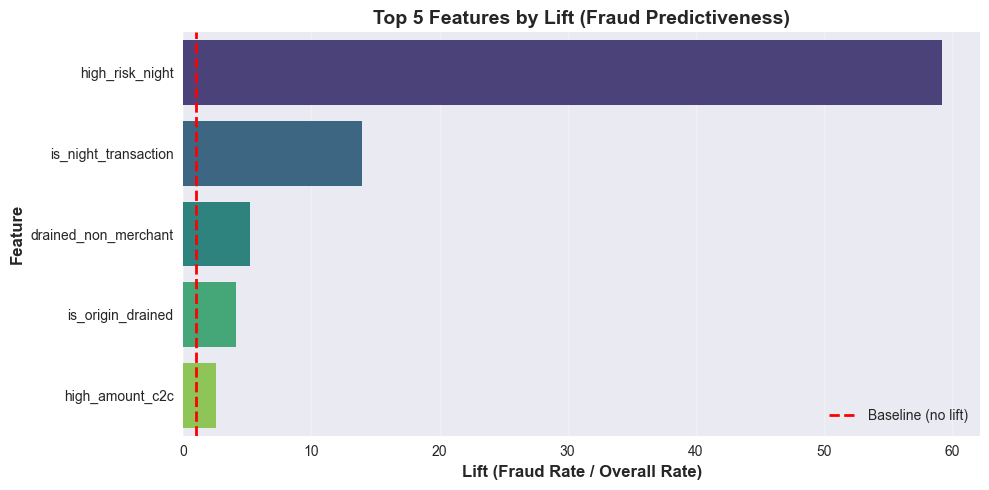


💡 Interpretation:
  • Features far to the right are strong fraud indicators
  • These features should be prioritized in model training
  • Baseline (red line) = feature appears equally in fraud and non-fraud


In [7]:
# Preview: Top features by lift (visualization)
print('\n📊 VISUALIZING TOP FEATURES BY LIFT')
print('='*80)

# Get top 5 features
top_features = fraud_analysis.nlargest(5, 'Lift')

plt.figure(figsize=(10, 5))
sns.barplot(data=top_features.reset_index(), y='index', x='Lift', palette='viridis')
plt.ylabel('Feature', fontsize=12, weight='bold')
plt.xlabel('Lift (Fraud Rate / Overall Rate)', fontsize=12, weight='bold')
plt.title('Top 5 Features by Lift (Fraud Predictiveness)', fontsize=14, weight='bold')
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Baseline (no lift)')
plt.legend(fontsize=10)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n💡 Interpretation:')
print('  • Features far to the right are strong fraud indicators')
print('  • These features should be prioritized in model training')
print('  • Baseline (red line) = feature appears equally in fraud and non-fraud')

---
## 7. Feature Correlation Analysis

### Why Check Correlations?

**Multicollinearity** (high correlation between features) can:
- Make linear model coefficients unstable
- Inflate variance in regression models
- Slow down training

**Note**: Tree-based models (XGBoost, Random Forest) handle multicollinearity well!


🔗 FEATURE CORRELATION ANALYSIS


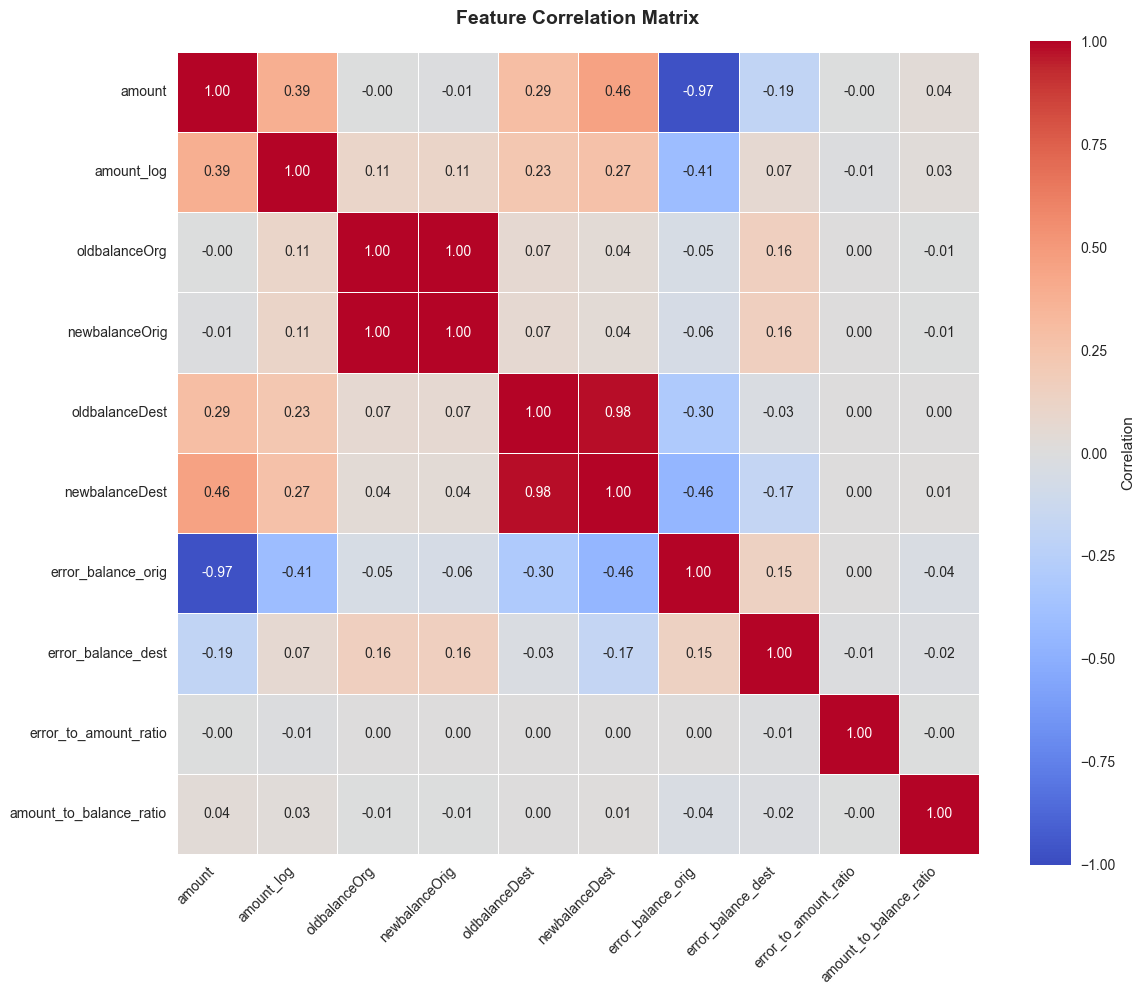


🔍 Checking for high correlations (|r| > 0.8)...

⚠️ High correlations detected (|r| > 0.8):
  • amount ↔ error_balance_orig: -0.971
  • oldbalanceOrg ↔ newbalanceOrig: 0.999
  • oldbalanceDest ↔ newbalanceDest: 0.977

💡 Explanation:
  • amount ↔ error_balance_orig: Mathematically related (error = old - amount - new)
  • oldbalanceOrg ↔ newbalanceOrig: Expected in legitimate transactions
  • oldbalanceDest ↔ newbalanceDest: Expected in legitimate transactions

✅ These correlations are EXPECTED and capture fraud patterns!
   In fraud cases, these relationships break down (our signal!)



In [8]:
print('\n' + '='*80)
print('🔗 FEATURE CORRELATION ANALYSIS')
print('='*80)

# Check for multicollinearity in numerical features
numerical_feats = [
    'amount', 'amount_log', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'error_balance_orig', 'error_balance_dest', 
    'error_to_amount_ratio', 'amount_to_balance_ratio'
]

corr_matrix = df_engineered[numerical_feats].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'},
            vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Flag highly correlated pairs (|r| > 0.8)
print('\n🔍 Checking for high correlations (|r| > 0.8)...')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))

if high_corr:
    print('\n⚠️ High correlations detected (|r| > 0.8):')
    for feat1, feat2, corr in high_corr:
        print(f'  • {feat1} ↔ {feat2}: {corr:.3f}')
    
    print('\n💡 Explanation:')
    print('  • amount ↔ error_balance_orig: Mathematically related (error = old - amount - new)')
    print('  • oldbalanceOrg ↔ newbalanceOrig: Expected in legitimate transactions')
    print('  • oldbalanceDest ↔ newbalanceDest: Expected in legitimate transactions')
    print('\n✅ These correlations are EXPECTED and capture fraud patterns!')
    print('   In fraud cases, these relationships break down (our signal!)\n')
else:
    print('\n✅ No problematic multicollinearity detected!')

print('='*80)

---
## 8. Multicollinearity Strategy

### Two Pipeline Approach

Since different model types handle multicollinearity differently:

| Model Type | Affected by Multicollinearity? | Strategy |
|------------|-------------------------------|----------|
| **Tree-based** (XGBoost, LightGBM, RF) | ❌ No | Keep all features |
| **Linear** (Logistic Regression) | ✅ Yes | Drop highly correlated features |

### Solution: Create Two Preprocessors

1. **`preprocessor_full.pkl`**: For tree-based models (keeps all features)
2. **`preprocessor_linear.pkl`**: For linear models (drops `newbalanceOrig`, `newbalanceDest`)

### Why This Works

- **Tree-based models** automatically select the most informative features at each split
- **Linear models** need independent features to avoid unstable coefficients
- We keep the **fraud signal** features (`error_balance_orig/dest`) in both!

In [9]:
print('\n' + '='*80)
print('🎯 MULTICOLLINEARITY STRATEGY')
print('='*80)

# Strategy 1: Full feature set (for tree-based models)
categorical_features = ['type']

numerical_features_full = [
    'amount', 'amount_log', 
    'oldbalanceOrg', 'newbalanceOrig',  # Keep both for tree models
    'oldbalanceDest', 'newbalanceDest',  # Keep both for tree models
    'error_balance_orig', 'error_balance_dest',
    'error_to_amount_ratio', 'amount_to_balance_ratio'
]

binary_features = [
    'hour', 'day', 'is_merchant_dest', 'is_origin_drained',
    'is_high_amount', 'is_night_transaction', 'is_high_risk_type',
    'high_risk_night', 'high_amount_c2c', 'drained_non_merchant'
]

all_features_full = categorical_features + numerical_features_full + binary_features

print(f'\n✅ Strategy 1 (Tree-based models): {len(all_features_full)} features')
print('   Models: XGBoost, LightGBM, Random Forest, CatBoost')
print('   Rationale: These models are robust to multicollinearity\n')

# Strategy 2: Reduced feature set (for linear models)
# Drop newbalanceOrig and newbalanceDest (keep old balances + amounts + errors)
numerical_features_linear = [
    'amount', 'amount_log', 
    'oldbalanceOrg',  # Drop newbalanceOrig
    'oldbalanceDest',  # Drop newbalanceDest
    'error_balance_orig', 'error_balance_dest',
    'error_to_amount_ratio', 'amount_to_balance_ratio'
]

all_features_linear = categorical_features + numerical_features_linear + binary_features

print(f'✅ Strategy 2 (Linear models): {len(all_features_linear)} features')
print('   Models: Logistic Regression')
print('   Dropped: newbalanceOrig, newbalanceDest')
print('   Rationale: Reduce multicollinearity for stable coefficients\n')

print('📦 We\'ll create and save TWO preprocessing pipelines:')
print('   1. preprocessor_full.pkl - For tree-based models (default)')
print('   2. preprocessor_linear.pkl - For logistic regression')

print('='*80)


🎯 MULTICOLLINEARITY STRATEGY

✅ Strategy 1 (Tree-based models): 21 features
   Models: XGBoost, LightGBM, Random Forest, CatBoost
   Rationale: These models are robust to multicollinearity

✅ Strategy 2 (Linear models): 19 features
   Models: Logistic Regression
   Dropped: newbalanceOrig, newbalanceDest
   Rationale: Reduce multicollinearity for stable coefficients

📦 We'll create and save TWO preprocessing pipelines:
   1. preprocessor_full.pkl - For tree-based models (default)
   2. preprocessor_linear.pkl - For logistic regression


---
## 9. Train-Validation-Test Split

### Stratified Split Strategy

For imbalanced fraud detection:
- Use **stratified split** to preserve fraud ratio (0.13%)
- Split: **70% train, 15% validation, 15% test**
- Same random seed for reproducibility

In [10]:
print('\n' + '='*80)
print('🔀 TRAIN-VALIDATION-TEST SPLIT')
print('='*80)

# Prepare X and y
X_full = df_engineered[all_features_full].copy()
X_linear = df_engineered[all_features_linear].copy()
y = df_engineered['isFraud'].copy()

print(f'\n📊 Dataset shape:')
print(f'  • Full feature set: {X_full.shape}')
print(f'  • Linear feature set: {X_linear.shape}')
print(f'  • Target (y): {y.shape}')
print(f'  • Fraud rate: {y.mean()*100:.4f}%')

# First split: 70% train, 30% temp (for val + test)
X_train_full, X_temp_full, y_train, y_temp = train_test_split(
    X_full, y, test_size=0.30, stratify=y, random_state=42
)

X_train_linear, X_temp_linear, _, _ = train_test_split(
    X_linear, y, test_size=0.30, stratify=y, random_state=42
)

# Second split: 15% val, 15% test (from the 30% temp)
X_val_full, X_test_full, y_val, y_test = train_test_split(
    X_temp_full, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

X_val_linear, X_test_linear, _, _ = train_test_split(
    X_temp_linear, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f'\n📊 Split sizes:')
print(f'  • Train: {len(X_train_full):,} ({len(X_train_full)/len(X_full)*100:.1f}%)')
print(f'  • Val:   {len(X_val_full):,} ({len(X_val_full)/len(X_full)*100:.1f}%)')
print(f'  • Test:  {len(X_test_full):,} ({len(X_test_full)/len(X_full)*100:.1f}%)')

print(f'\n📊 Fraud rates (stratification check):')
print(f'  • Train: {y_train.mean()*100:.4f}%')
print(f'  • Val:   {y_val.mean()*100:.4f}%')
print(f'  • Test:  {y_test.mean()*100:.4f}%')

print(f'\n✅ Stratified split preserves fraud ratio across all sets!')
print('='*80)


🔀 TRAIN-VALIDATION-TEST SPLIT

📊 Dataset shape:
  • Full feature set: (6362620, 21)
  • Linear feature set: (6362620, 19)
  • Target (y): (6362620,)
  • Fraud rate: 0.1291%

📊 Split sizes:
  • Train: 4,453,834 (70.0%)
  • Val:   954,393 (15.0%)
  • Test:  954,393 (15.0%)

📊 Fraud rates (stratification check):
  • Train: 0.1291%
  • Val:   0.1291%
  • Test:  0.1291%

✅ Stratified split preserves fraud ratio across all sets!


---
## 10. Build Preprocessing Pipelines

### Production-Ready Pipelines

We create **two sklearn ColumnTransformers**:

#### Pipeline 1: Full Features (Tree-based)
- **Categorical**: OneHotEncoder for `type`
- **Numerical**: StandardScaler for 10 features
- **Binary**: Passthrough for 10 features

#### Pipeline 2: Linear Features (Logistic)
- **Categorical**: OneHotEncoder for `type`
- **Numerical**: StandardScaler for 8 features (drops 2)
- **Binary**: Passthrough for 10 features

### Why This Design?

- ✅ **Prevents leakage**: Fitted on train only
- ✅ **Consistent**: Same transformation for val/test
- ✅ **Serializable**: Save and load for production
- ✅ **Model-specific**: Optimal features for each model type

In [11]:
print('\n' + '='*80)
print('⚙️ BUILDING PREPROCESSING PIPELINES')
print('='*80)

# Pipeline 1: Full feature set (for tree-based models)
preprocessor_full = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), 
         categorical_features),
        ('num', StandardScaler(), numerical_features_full),
        ('bin', 'passthrough', binary_features)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

print('\n✅ Preprocessor 1 (Full): Created for tree-based models')
print(f'   • Categorical: {len(categorical_features)} features')
print(f'   • Numerical: {len(numerical_features_full)} features')
print(f'   • Binary: {len(binary_features)} features')

# Pipeline 2: Reduced feature set (for linear models)
preprocessor_linear = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), 
         categorical_features),
        ('num', StandardScaler(), numerical_features_linear),
        ('bin', 'passthrough', binary_features)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

print('\n✅ Preprocessor 2 (Linear): Created for Logistic Regression')
print(f'   • Categorical: {len(categorical_features)} features')
print(f'   • Numerical: {len(numerical_features_linear)} features (2 dropped)')
print(f'   • Binary: {len(binary_features)} features')

print('='*80)


⚙️ BUILDING PREPROCESSING PIPELINES

✅ Preprocessor 1 (Full): Created for tree-based models
   • Categorical: 1 features
   • Numerical: 10 features
   • Binary: 10 features

✅ Preprocessor 2 (Linear): Created for Logistic Regression
   • Categorical: 1 features
   • Numerical: 8 features (2 dropped)
   • Binary: 10 features


---
## 11. Fit and Transform Data

### Process

1. **Fit** both pipelines on training data only
2. **Transform** train, val, and test sets
3. Verify output shapes
4. Check for any issues

In [12]:
print('\n' + '='*80)
print('⚙️ FITTING AND TRANSFORMING DATA')
print('='*80)

# Fit and transform - FULL pipeline
print('\n⏳ Fitting full preprocessor on training data...')
X_train_full_transformed = preprocessor_full.fit_transform(X_train_full)
X_val_full_transformed = preprocessor_full.transform(X_val_full)
X_test_full_transformed = preprocessor_full.transform(X_test_full)

print(f'✅ Full pipeline fitted and applied!')
print(f'   • Train: {X_train_full_transformed.shape}')
print(f'   • Val:   {X_val_full_transformed.shape}')
print(f'   • Test:  {X_test_full_transformed.shape}')

# Fit and transform - LINEAR pipeline
print('\n⏳ Fitting linear preprocessor on training data...')
X_train_linear_transformed = preprocessor_linear.fit_transform(X_train_linear)
X_val_linear_transformed = preprocessor_linear.transform(X_val_linear)
X_test_linear_transformed = preprocessor_linear.transform(X_test_linear)

print(f'✅ Linear pipeline fitted and applied!')
print(f'   • Train: {X_train_linear_transformed.shape}')
print(f'   • Val:   {X_val_linear_transformed.shape}')
print(f'   • Test:  {X_test_linear_transformed.shape}')

# Get feature names
feature_names_full = preprocessor_full.get_feature_names_out()
feature_names_linear = preprocessor_linear.get_feature_names_out()

print(f'\n📊 Final feature counts:')
print(f'   • Full pipeline: {len(feature_names_full)} features (after one-hot encoding)')
print(f'   • Linear pipeline: {len(feature_names_linear)} features (after one-hot encoding)')

print('='*80)


⚙️ FITTING AND TRANSFORMING DATA

⏳ Fitting full preprocessor on training data...
✅ Full pipeline fitted and applied!
   • Train: (4453834, 24)
   • Val:   (954393, 24)
   • Test:  (954393, 24)

⏳ Fitting linear preprocessor on training data...
✅ Linear pipeline fitted and applied!
   • Train: (4453834, 22)
   • Val:   (954393, 22)
   • Test:  (954393, 22)

📊 Final feature counts:
   • Full pipeline: 24 features (after one-hot encoding)
   • Linear pipeline: 22 features (after one-hot encoding)


---
## 12. Save All Artifacts

### Artifact Structure

```
artifacts/
├── data/
│   ├── raw_data.csv          # ✅ Original data backup
│   ├── train.csv             # ✅ Training set (70%)
│   ├── val.csv               # ✅ Validation set (15%)
│   └── test.csv              # ✅ Test set (15%)
├── preprocessor_full.pkl     # ✅ For tree-based models
├── preprocessor_linear.pkl   # ✅ For logistic regression
└── feature_config.pkl        # ✅ Feature metadata
```

### What Gets Saved

1. **Preprocessors**: Fitted pipelines for both strategies
2. **CSV Files**: Transformed train/val/test data
3. **Feature Config**: Column names and metadata
4. **Target Arrays**: y_train, y_val, y_test

In [13]:
print('\n' + '='*80)
print('💾 SAVING ARTIFACTS TO MAIN PROJECT FOLDER')
print('='*80)

# Save preprocessors
joblib.dump(preprocessor_full, '../artifacts/preprocessor_full.pkl')
print('✅ Saved: ../artifacts/preprocessor_full.pkl (for XGBoost, LightGBM, RF, CatBoost)')

joblib.dump(preprocessor_linear, '../artifacts/preprocessor_linear.pkl')
print('✅ Saved: ../artifacts/preprocessor_linear.pkl (for Logistic Regression)')

# Save feature configuration
feature_config = {
    'categorical_features': categorical_features,
    'numerical_features_full': numerical_features_full,
    'numerical_features_linear': numerical_features_linear,
    'binary_features': binary_features,
    'all_features_full': all_features_full,
    'all_features_linear': all_features_linear,
    'feature_names_full': list(feature_names_full),
    'feature_names_linear': list(feature_names_linear),
    'target': 'isFraud',
    'created_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open('../artifacts/feature_config.pkl', 'wb') as f:
    pickle.dump(feature_config, f)
print('✅ Saved: ../artifacts/feature_config.pkl')

# Convert transformed arrays to DataFrames and save as CSV
print('\n⏳ Saving transformed datasets as CSV files...')

# Use full pipeline data by default (tree-based models are primary)
train_df = pd.DataFrame(X_train_full_transformed, columns=feature_names_full)
train_df['isFraud'] = y_train.values
train_df.to_csv('../artifacts/data/train.csv', index=False)
print(f'✅ Saved: ../artifacts/data/train.csv ({len(train_df):,} rows)')

val_df = pd.DataFrame(X_val_full_transformed, columns=feature_names_full)
val_df['isFraud'] = y_val.values
val_df.to_csv('../artifacts/data/val.csv', index=False)
print(f'✅ Saved: ../artifacts/data/val.csv ({len(val_df):,} rows)')

test_df = pd.DataFrame(X_test_full_transformed, columns=feature_names_full)
test_df['isFraud'] = y_test.values
test_df.to_csv('../artifacts/data/test.csv', index=False)
print(f'✅ Saved: ../artifacts/data/test.csv ({len(test_df):,} rows)')

print('\n' + '='*80)
print('✅ ALL ARTIFACTS SAVED TO MAIN PROJECT FOLDER')
print('='*80)

# Display summary
print('\n📊 PIPELINE SUMMARY:')
print(f'  • Original features: 11')
print(f'  • Engineered features: {len(all_features_full)}')
print(f'  • Final features (full): {len(feature_names_full)} (after one-hot encoding)')
print(f'  • Final features (linear): {len(feature_names_linear)} (after one-hot encoding)')
print(f'\n  • Training samples: {len(train_df):,} ({y_train.mean()*100:.4f}% fraud)')
print(f'  • Validation samples: {len(val_df):,} ({y_val.mean()*100:.4f}% fraud)')
print(f'  • Test samples: {len(test_df):,} ({y_test.mean()*100:.4f}% fraud)')
print('\n🎯 Ready for model training!')
print('='*80)


💾 SAVING ARTIFACTS TO MAIN PROJECT FOLDER
✅ Saved: ../artifacts/preprocessor_full.pkl (for XGBoost, LightGBM, RF, CatBoost)
✅ Saved: ../artifacts/preprocessor_linear.pkl (for Logistic Regression)
✅ Saved: ../artifacts/feature_config.pkl

⏳ Saving transformed datasets as CSV files...
✅ Saved: ../artifacts/data/train.csv (4,453,834 rows)
✅ Saved: ../artifacts/data/val.csv (954,393 rows)
✅ Saved: ../artifacts/data/test.csv (954,393 rows)

✅ ALL ARTIFACTS SAVED TO MAIN PROJECT FOLDER

📊 PIPELINE SUMMARY:
  • Original features: 11
  • Engineered features: 21
  • Final features (full): 24 (after one-hot encoding)
  • Final features (linear): 22 (after one-hot encoding)

  • Training samples: 4,453,834 (0.1291% fraud)
  • Validation samples: 954,393 (0.1291% fraud)
  • Test samples: 954,393 (0.1291% fraud)

🎯 Ready for model training!


---
## 13. Summary & Next Steps

### ✅ What We Accomplished

1. **Loaded 6.36M transactions** from PaySim dataset
2. **Created 15 high-impact features** (streamlined approach):
   - 2 temporal features
   - 4 balance error features  
   - 3 amount features
   - 3 pattern features
   - 3 interaction features
3. **Analyzed feature importance** via lift analysis
4. **Checked correlations** and identified multicollinearity
5. **Built TWO pipelines** to handle model-specific needs:
   - `preprocessor_full.pkl` for tree-based models
   - `preprocessor_linear.pkl` for logistic regression
6. **Performed stratified split** (70/15/15)
7. **Saved all artifacts** to main project folder

---

## 📊 Final Statistics

| Metric | Value |
|--------|-------|
| Original Features | 11 |
| Engineered Features | 21 |
| Final Features (Full) | ~25 (after one-hot encoding) |
| Final Features (Linear) | ~23 (after one-hot encoding) |
| Training Samples | ~4.45M (70%) |
| Validation Samples | ~0.95M (15%) |
| Test Samples | ~0.95M (15%) |
| Fraud Rate | 0.13% |

